<a href="https://colab.research.google.com/github/guru-ppriyan/ml_intern_cognifyz/blob/main/Restaurant_rating_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
from google.colab import files

uploaded = files.upload()

Saving Dataset  (1).csv to Dataset  (1) (1).csv


In [12]:
import os

os.listdir()

['.config', 'Dataset  (1) (1).csv', 'Dataset  (1).csv', 'sample_data']

In [14]:
filename = next(iter(uploaded))
print("File:", filename)

df = pd.read_csv(filename)
df.head()

File: Dataset  (1) (1).csv


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [15]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (9551, 21)

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Missing Values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Duplicate Rows: 0


In [16]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing cuisine values
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

print("Dataset shape after cleaning:", df.shape)

Missing values after cleaning:
0
Dataset shape after cleaning: (9551, 21)


In [17]:
features = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Has Table booking",
    "Has Online delivery",
    "City",
    "Cuisines"
]

X = df[features]
y = df["Aggregate rating"]

print("Features selected:", features)
print("Target: Aggregate rating")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features selected: ['Average Cost for two', 'Price range', 'Votes', 'Has Table booking', 'Has Online delivery', 'City', 'Cuisines']
Target: Aggregate rating
X shape: (9551, 7)
y shape: (9551,)


In [18]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['Average Cost for two', 'Price range', 'Votes']

Categorical Features:
['Has Table booking', 'Has Online delivery', 'City', 'Cuisines']


In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing setup completed.")

Preprocessing setup completed.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7640, 7)
Testing data: (1911, 7)


In [24]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [25]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [26]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [27]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

results = [
    evaluate_model(y_test, linear_predictions, "Linear Regression"),
    evaluate_model(y_test, tree_predictions, "Decision Tree"),
    evaluate_model(y_test, rf_predictions, "Random Forest")
]

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.991674,1.461844,1.209068,0.357744
1,Decision Tree,0.257230,0.166921,0.408559,0.926664
2,Random Forest,0.205047,0.102352,0.319925,0.955032


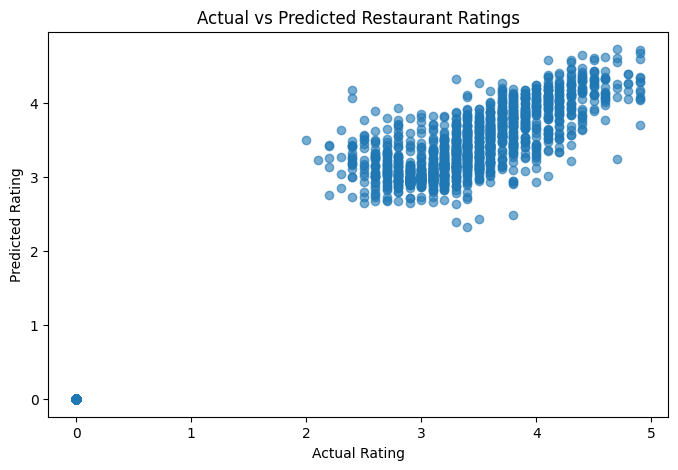

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_predictions, alpha=0.6)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Restaurant Ratings")

plt.show()

In [30]:
rf_importance = rf_model.named_steps["model"].feature_importances_

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
2,num__Votes,0.950121
0,num__Average Cost for two,0.008913
1,num__Price range,0.003032
87,cat__City_New Delhi,0.002344
88,cat__City_Noida,0.001712
53,cat__City_Gurgaon,0.001103
5,cat__Has Online delivery_No,0.000993
1255,"cat__Cuisines_North Indian, Chinese",0.000982
6,cat__Has Online delivery_Yes,0.000941
108,cat__City_Rio de Janeiro,0.000903


In [31]:
rf_importance = rf_model.named_steps["model"].feature_importances_

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
2,num__Votes,0.950121
0,num__Average Cost for two,0.008913
1,num__Price range,0.003032
87,cat__City_New Delhi,0.002344
88,cat__City_Noida,0.001712
53,cat__City_Gurgaon,0.001103
5,cat__Has Online delivery_No,0.000993
1255,"cat__Cuisines_North Indian, Chinese",0.000982
6,cat__Has Online delivery_Yes,0.000941
108,cat__City_Rio de Janeiro,0.000903


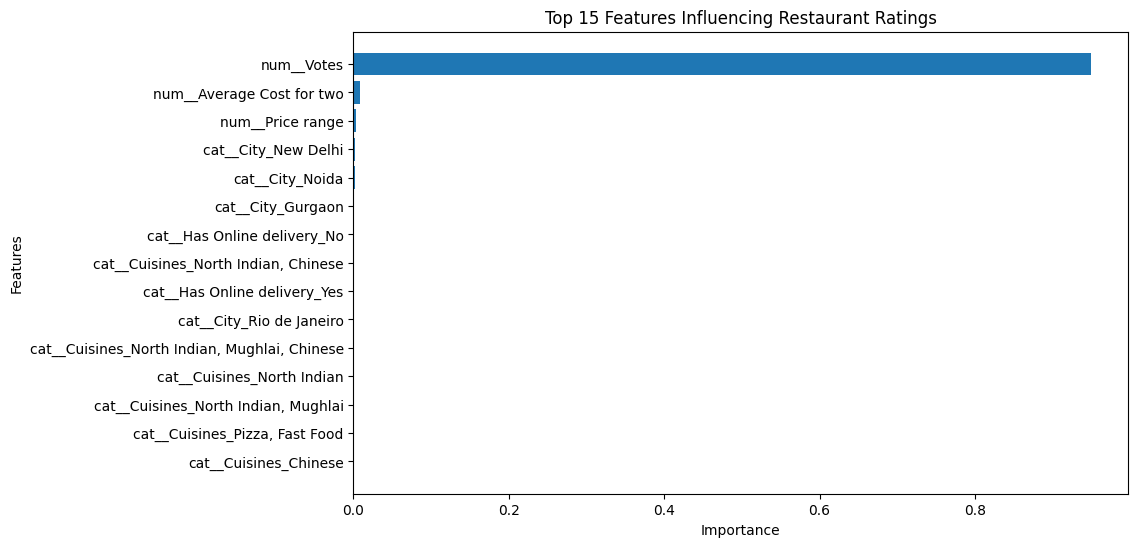

In [32]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Features Influencing Restaurant Ratings")
plt.gca().invert_yaxis()

plt.show()

In [33]:
best_model = results_df.loc[results_df["R2 Score"].idxmax(), "Model"]

print("Best Model:", best_model)
print("Best R2 Score:", results_df["R2 Score"].max())
print("\nTask 1 completed successfully.")

Best Model: Random Forest
Best R2 Score: 0.9550321618717376

Task 1 completed successfully.


The restaurant rating prediction model was developed using Linear Regression, Decision Tree Regression, and Random Forest Regression. Among the three models, Random Forest performed the best with an R² score of 0.955 and an RMSE of 0.320. The results show that the Random Forest model can effectively predict restaurant ratings based on features such as cost, price range, votes, booking and delivery options, city, and cuisines. Feature importance analysis was also performed to identify the factors that contribute most to rating prediction.